<a href="https://colab.research.google.com/github/ha22756/ha22756/blob/main/hanan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from scipy.io import loadmat


File JPCNN001_small.mat already exists locally. Skipping download.
130.5943260192871
57.61212251309106


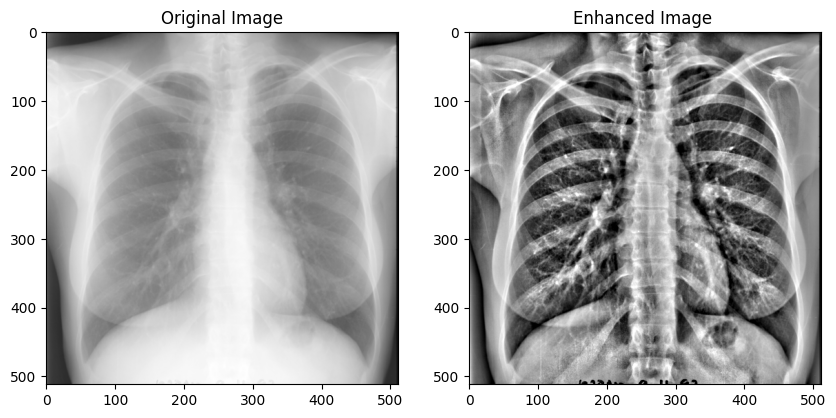

In [10]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from scipy.io import loadmat
import urllib.request
import os

# URL of the .mat file
mat_file_url = 'https://github.com/ha22756/images/raw/refs/heads/main/JPCNN001_small.mat'

# Define a local path to save the .mat file
local_mat_file_path = 'JPCNN001_small.mat'

# Download the .mat file if it doesn't exist locally
if not os.path.exists(local_mat_file_path):
    print(f"Downloading {mat_file_url} to {local_mat_file_path}...")
    urllib.request.urlretrieve(mat_file_url, local_mat_file_path)
    print("Download complete.")
else:
    print(f"File {local_mat_file_path} already exists locally. Skipping download.")

# تحميل ملف MAT من المسار المحلي
data = loadmat(local_mat_file_path)

# استخراج الصورة (تأكد من اسم المتغير داخل ملف MAT)
image = data['jrst']['cxr'][0][0]


def local_contrast(image, gauss_std=5):
    # تحويل الصورة إلى نوع عشري
    image = image.astype(np.float64)

    # تقدير المتوسط الموضعي باستخدام مرشح غاوسي
    local_mean = gaussian_filter(image, sigma=gauss_std)

    # حساب الفارق بين الصورة والمدى الموضعي
    low_pass = image - local_mean

    # حساب التباين الموضعي
    variance = gaussian_filter(low_pass ** 2, sigma=gauss_std)

    # حساب الانحراف المعياري
    std_dev = np.sqrt(variance)

    # تجنب القسمة على صفر
    std_dev[std_dev == 0] = np.mean(std_dev[std_dev != 0])

    # تحسين التباين وإخراج الصورة
    enhanced_image = 64 * (low_pass / std_dev) + 127

    # قص القيم إلى النطاق [0, 255]
    enhanced_image = np.clip(enhanced_image, 0, 255)

    # تحويل إلى uint8
    return enhanced_image.astype(np.uint8)

# تطبيق تحسين التباين الموضعي
enhanced_image = local_contrast(image, gauss_std=15)

# طباعة المتوسط والانحراف المعياري للصورة المعززة
print(np.mean(enhanced_image))
print(np.std(enhanced_image))


# عرض النتائج
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Enhanced Image ")
plt.imshow(enhanced_image, cmap='gray')
plt.show()

In [ ]:
print(image.shape)
print(f"Intensity of the first pixel: {image[:, 511]}")

(512, 512)
Intensity of the first pixel: [165 160 160 160 160 160 160 160 160 160 160 160 160 162 182 182 162 160
 160 160 160 160 163 174 189 194 210 233 256 290 324 361 358 333 333 331
 353 358 373 383 386 395 409 413 431 443 457 473 491 509 526 541 558 575
 590 602 611 624 630 631 641 643 642 650 669 673 680 692 687 693 705 693
 699 705 699 707 709 704 706 709 710 713 704 694 695 698 688 691 682 678
 675 679 685 691 698 690 701 696 705 698 716 713 715 725 730 738 752 760
 748 750 745 757 766 775 792 798 799 778 742 719 709 703 699 704 697 692
 697 689 678 677 670 661 670 672 670 662 668 660 657 656 653 650 648 644
 652 645 642 628 635 634 626 624 627 617 615 612 617 606 611 600 595 592
 588 575 571 562 559 548 543 536 535 521 527 515 514 514 506 500 506 502
 499 477 450 441 421 406 392 383 360 343 324 305 293 283 259 247 221 201
 189 176 162 161 160 160 160 160 160 160 160 160 160 160 160 160 160 160
 160 160 160 160 160 160 160 160 160 160 160 160 160 160 160 160 160 160
 160 160 1

In [ ]:
import os
import cv2

# Define the path for the new folder in Google Drive
output_folder_path = '/content/drive/MyDrive/my results'

# Create the folder if it doesn't exist
if not os.path.exists(output_folder_path):
    os.makedirs(output_folder_path)
    print(f"Folder '{output_folder_path}' created.")
else:
    print(f"Folder '{output_folder_path}' already exists.")

# Define the path to save the enhanced image
output_image_path = os.path.join(output_folder_path, 'enhanced_image.png')

# Save the enhanced_image (assuming it's a uint8 image as processed earlier)
cv2.imwrite(output_image_path, enhanced_image)

print(f"Enhanced image saved to: {output_image_path}")

Folder '/content/drive/MyDrive/my results' created.
Enhanced image saved to: /content/drive/MyDrive/my results/enhanced_image.png


In [ ]:
import numpy as np
from scipy.io import savemat
import os

# Ensure the output folder path is defined and exists (from previous steps)
output_folder_path = '/content/drive/MyDrive/my results'
if not os.path.exists(output_folder_path):
    os.makedirs(output_folder_path)

# Calculate histogram data
# np.histogram returns (counts, bin_edges)
counts, bin_edges = np.histogram(image.flatten(), bins=50)

# Define the path to save the .mat file
output_mat_path = os.path.join(output_folder_path, 'image_histogram_data.mat')

# Save the histogram data to a .mat file
savemat(output_mat_path, {'histogram_counts': counts, 'histogram_bin_edges': bin_edges})

print(f"Histogram data saved to: {output_mat_path}")

Histogram data saved to: /content/drive/MyDrive/my results/image_histogram_data.mat


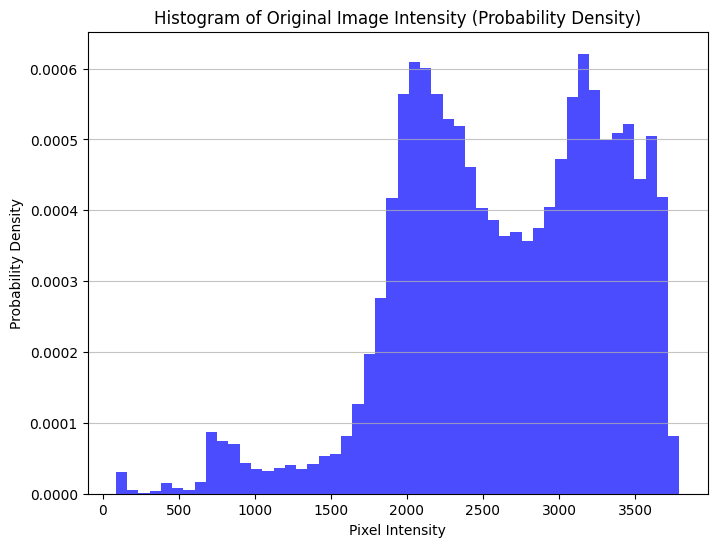

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(image.flatten(), bins=50, color='blue', alpha=0.7, density=True)
plt.title('Histogram of Original Image Intensity (Probability Density)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Probability Density')
plt.grid(axis='y', alpha=0.75)
plt.show()

Min intensity of normalized image: 0.0
Max intensity of normalized image: 1.0


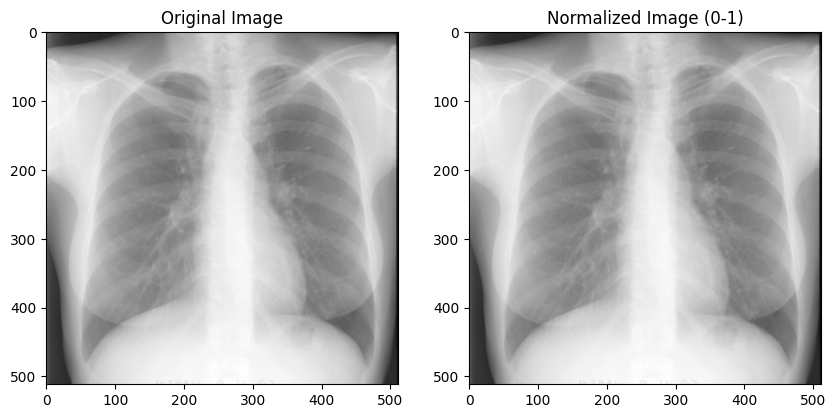

In [ ]:
# Normalize the image to a 0-1 range
normalized_image = (image - image.min()) / (image.max() - image.min())

print(f"Min intensity of normalized image: {normalized_image.min()}")
print(f"Max intensity of normalized image: {normalized_image.max()}")

# Display the normalized image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Normalized Image (0-1)")
plt.imshow(normalized_image, cmap='gray')
plt.show()